# Stage 7 — Full GPT + Training Loop

Stack the transformer blocks from Stage 6 into a full decoder-only LM, then train it on the Mahabharata token stream.

Model layout:

```
ids → tok_emb + pos_emb → dropout
    → N × TransformerBlock
    → LayerNorm
    → Linear (lm_head)  →  logits over vocab
```

The training loop is intentionally small — designed to fit in a notebook, not to set records. Tune `n_layers`, `emb_dim`, `max_iters` upward if you have a GPU.

In [1]:
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn

from model import GPTModel  # blocks defined in model.py (mirror of stage 6)

torch.manual_seed(123)
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', device)

device: mps


## Config

A tiny GPT — ~10M params. Big enough to learn the corpus pattern, small enough to train on CPU/MPS in minutes.

In [2]:
CFG = {
    'vocab_size'  : 50257,   # GPT-2 BPE
    'context_len' : 128,
    'emb_dim'     : 256,
    'n_heads'     : 8,
    'n_layers'    : 4,
    'drop_rate'   : 0.1,
    'qkv_bias'    : False,
}

BATCH_SIZE   = 16
LR           = 3e-4
WEIGHT_DECAY = 0.1
MAX_ITERS    = 1000     # bump this up for real training
EVAL_EVERY   = 100
EVAL_BATCHES = 20

## Data loader

Random-batch sampling from the flat token array — standard nanoGPT-style. Each batch is `B` random windows of length `T`, with targets shifted by one.

In [3]:
proc = Path('data/processed')
train_ids = np.fromfile(proc / 'train.bin', dtype=np.uint16).astype(np.int64)
val_ids   = np.fromfile(proc / 'val.bin',   dtype=np.uint16).astype(np.int64)
print(f'train tokens: {len(train_ids):,}   val tokens: {len(val_ids):,}')

T = CFG['context_len']

def get_batch(split: str):
    ids = train_ids if split == 'train' else val_ids
    starts = np.random.randint(0, len(ids) - T - 1, size=BATCH_SIZE)
    x = np.stack([ids[i:i+T]       for i in starts])
    y = np.stack([ids[i+1:i+1+T]   for i in starts])
    return (torch.tensor(x, dtype=torch.long, device=device),
            torch.tensor(y, dtype=torch.long, device=device))

xb, yb = get_batch('train')
print('batch:', xb.shape, yb.shape)

train tokens: 362,720   val tokens: 39,654
batch: torch.Size([16, 128]) torch.Size([16, 128])


## Build the model

In [4]:
model = GPTModel(CFG).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'GPT params: {n_params:,}  (~{n_params/1e6:.2f}M)')

# Forward shape check.
with torch.no_grad():
    logits = model(xb)
print('logits:', logits.shape)  # (B, T, vocab_size)

GPT params: 28,920,832  (~28.92M)
logits: torch.Size([16, 128, 50257])


## Loss helper + eval

`cross_entropy` expects flat `(N, vocab)` and `(N,)` — we reshape `(B*T, V)` and `(B*T,)`.

In [5]:
import torch.nn.functional as F

def loss_for(xb, yb):
    logits = model(xb)
    B, T, V = logits.shape
    return F.cross_entropy(logits.view(B * T, V), yb.view(B * T))

@torch.no_grad()
def estimate_loss():
    model.eval()
    out = {}
    for split in ('train', 'val'):
        losses = torch.zeros(EVAL_BATCHES)
        for k in range(EVAL_BATCHES):
            xb, yb = get_batch(split)
            losses[k] = loss_for(xb, yb).item()
        out[split] = losses.mean().item()
    model.train()
    return out

## Train

AdamW with weight decay 0.1 (GPT-2 recipe), gradient clipping at 1.0.

On a fresh init, loss should start near `ln(50257) ≈ 10.8` and drop fast in the first hundred steps.

In [6]:
optim = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.95))

history = []
t0 = time.time()
model.train()
for step in range(1, MAX_ITERS + 1):
    xb, yb = get_batch('train')
    loss = loss_for(xb, yb)
    optim.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optim.step()

    if step % EVAL_EVERY == 0 or step == 1:
        m = estimate_loss()
        elapsed = time.time() - t0
        history.append((step, m['train'], m['val']))
        print(f'step {step:>5d}  train {m["train"]:.4f}  val {m["val"]:.4f}  ({elapsed:.1f}s)')

print(f'\nTotal training time: {time.time() - t0:.1f}s')

step     1  train 10.8726  val 10.8779  (6.0s)
step   100  train 6.2034  val 6.3190  (31.5s)
step   200  train 5.5326  val 5.7694  (57.5s)
step   300  train 5.0650  val 5.3733  (83.4s)
step   400  train 4.8602  val 5.2134  (109.4s)
step   500  train 4.7388  val 5.0186  (135.2s)
step   600  train 4.5674  val 5.0053  (161.3s)
step   700  train 4.4594  val 4.9454  (187.6s)
step   800  train 4.2206  val 4.9053  (213.8s)
step   900  train 4.3599  val 4.8434  (240.7s)
step  1000  train 4.1805  val 4.7338  (267.7s)

Total training time: 267.7s


## Loss curve

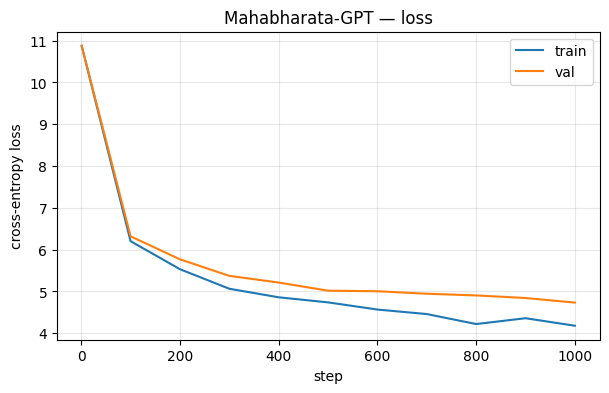

In [7]:
import matplotlib.pyplot as plt

steps  = [h[0] for h in history]
tr     = [h[1] for h in history]
va     = [h[2] for h in history]

plt.figure(figsize=(7, 4))
plt.plot(steps, tr, label='train')
plt.plot(steps, va, label='val')
plt.xlabel('step'); plt.ylabel('cross-entropy loss')
plt.title('Mahabharata-GPT — loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## Save the checkpoint

Stage 8 will load this to generate text.

In [8]:
ckpt_dir = Path('checkpoints'); ckpt_dir.mkdir(exist_ok=True)
ckpt_path = ckpt_dir / 'mahabharata_gpt.pt'
torch.save({'model_state': model.state_dict(), 'cfg': CFG}, ckpt_path)
print('saved:', ckpt_path, f'({ckpt_path.stat().st_size / 1e6:.1f} MB)')

saved: checkpoints/mahabharata_gpt.pt (115.8 MB)


## Quick sample (greedy)

Sanity check that the trained model produces *something* — not gibberish bytes. Real sampling (temperature, top-k) is in Stage 8.

In [9]:
import tiktoken
tok = tiktoken.get_encoding('gpt2')

@torch.no_grad()
def greedy_generate(prompt: str, max_new: int = 80):
    model.eval()
    ids = torch.tensor([tok.encode(prompt)], dtype=torch.long, device=device)
    for _ in range(max_new):
        ctx = ids[:, -CFG['context_len']:]
        logits = model(ctx)[:, -1, :]
        next_id = logits.argmax(dim=-1, keepdim=True)
        ids = torch.cat([ids, next_id], dim=1)
    return tok.decode(ids[0].tolist())

print(greedy_generate('Arjuna said,'))

Arjuna said, "O son of the Pandavas, I will be slain by the Pandavas. I will be able to be able to be able to be slain. I will be able to be able to be able to be able to the Pandavas. I will be able to the Pandavas. I will be able to the Pandavas. I will be able to the Pandav


Next: `08_generation.ipynb` — proper sampling with temperature and top-k for less-repetitive output.